# Laboratorio de regresión - 3

---
Nombre: **Alan Jesús Hernández Soto** \
Carrera: **Ingeniería Financiera** \
Materia: **Laboratorio de Aprendizaje Estadístico** \
Tipo de Trabajo: **Laboratorio**

---

## Análisis exploratorio de datos y limpieza

En los laboratorios y clases anteriores se ha visto que el modelo de regresión propuesto puede ser cualquier combinación lineal de factores independientes. Por lo tanto hay un número infinito de posibles modelos de regresión teóricos. ¿Cómo podemos deducir qué tipo de modelo podríamos necesitar?

**Anteriormente viendo la gráfica de dispersión de los datos podríamos decir con facilidad que las observaciones tenian comportamiento lineales, así mismo en base a intuición de la relación entre variables**

### EDA

El primer paso antes de poder proponer un modelo para predecir datos es entender el conjunto de datos con el que se está trabajando.
- ¿Cuántas muestras tiene?
- ¿Cuántos factores tiene?
- ¿Quién o qué hizo la recolección de las observaciones?
- ¿Cómo se hizo el muestreo?
- ¿En qué año se hicieron las observaciones?
- ¿En dónde se realizaron las observaciones?

El propósito de un análisis exploratorio de datos (EDA - Exploratory Data Analysis) es entender la naturaleza de los datos, comprender las relaciones existentes entre las variables para poder realizar hipótesis sobre cómo se relaciona la variable dependiente con las independientes.

#### Ejercicio 1: Dataset

Utiliza el dataset "Heart Prediction Dataset (Quantum)". Carga los datos y revisa qué factores contiene.

In [252]:
import pandas as pd

df = pd.read_csv('Datasets/Heart Prediction Quantum Dataset.csv')
df

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,Hombre,105.00,191,107,1
1,58,Mujer,97.00,249,89,0
2,44,Mujer,93.00,190,82,1
3,72,Hombre,93.00,183,101,1
4,37,Mujer,145.00,166,103,1
...,...,...,...,...,...,...
495,34,Mujer,126.00,292,116,0
496,41,Mujer,164.00,248,114,0
497,45,Hombre,159.00,175,75,0
498,55,Mujer,107.00,157,101,1


In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            500 non-null    int64 
 1   Gender         500 non-null    object
 2   BloodPressure  500 non-null    object
 3   Cholesterol    500 non-null    int64 
 4   HeartRate      500 non-null    int64 
 5   HeartDisease   500 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 23.6+ KB


In [254]:
df.describe()

,Age,Cholesterol,HeartRate,HeartDisease
count,500.000000,500.00000,500.000000,500.000000
mean,54.864000,221.50000,88.766000,0.600000
std,14.315004,43.86363,17.417289,0.490389
min,30.000000,150.00000,60.000000,0.000000
25%,43.000000,183.75000,73.000000,0.000000
50%,55.000000,221.00000,89.000000,1.000000
75%,66.250000,258.00000,104.000000,1.000000
max,79.000000,299.00000,119.000000,1.000000


Para cada factor, escribe qué significa cada variable.
- ¿Qué tipo de datos se observaron?
    - Numéricos
        - Enteros
        - Flotantes
    - Categóricos
        - Ordinales
        - No ordinales
- ¿Qué rango de valores sería esperado que contuviera cada factor? E.g. No esperaría encontrar un valor de Age de $-4$.

Investiga los valores esperados para variables que no entiendas como BloodPressure, Cholesterol, etc.

 **Age**: Variable numérica, positiva y entera que va de 30 a 79 años que describe la edad es decir tiempo vivído de la persona. \
 **Gender**: Variable cualitatíva binaria que describe el genero de la persona. \
 **BloodPressure**: Variable numérica, positiva y decimal que describe la fuerza que ejerce la sangre contra las paredes de las arterias al latir el corazón (Presión Arterial), tiene un valor normal menor a 120/80 mmHg (Sistólica/Diastólica). \
 **Cholesterol**: Variable numérica, positiva y entera que describe la cantidad total de sustancia grasa presente en la sangre, donde se busca mantener bajo el colesterol LDL y alto el HDL, tiene un valor normal menor a 200 mg/dL. \
 **HeartRate**: Variable numérica, positiva y entera que describe el número de veces que el corazón se contrae o late por minuto, tiene un valor normal (En reposo) de entre 60 y 100 latidos por minuto (lpm). \
 **HeartDisease**: Variable númerica binaria que describe el valor cualitativo de si el sujeto tiene o no enfermedad cardíaca.

A partir de lo investigado, describe el dataset con tus palabras.

**El Dataset es un conjunto de 500 observaciones de la presión arterial, el colesterol y la frecuencia cardíaca sobre adultos de entre 30 y 79 con y sín enfermedades cardíacas**

#### Ejercicio 2: Factores

Ahora que se tiene un mejor entendimiento del dataset y de los valores que podría tener cada variable, es momento de revisar que las observaciones en el dataset estén dentro de ese rango esperado.

Crea un histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución. 

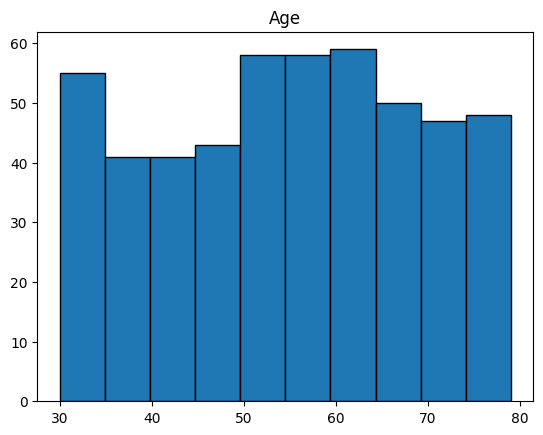

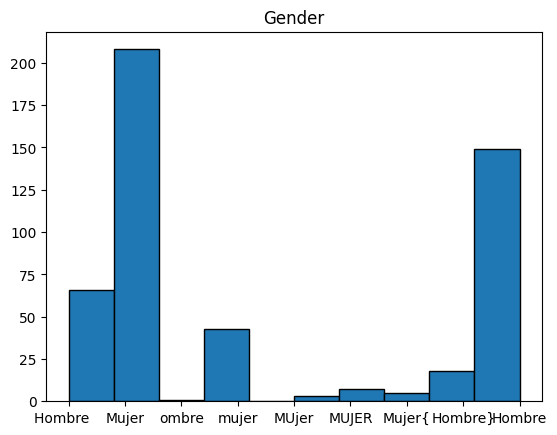

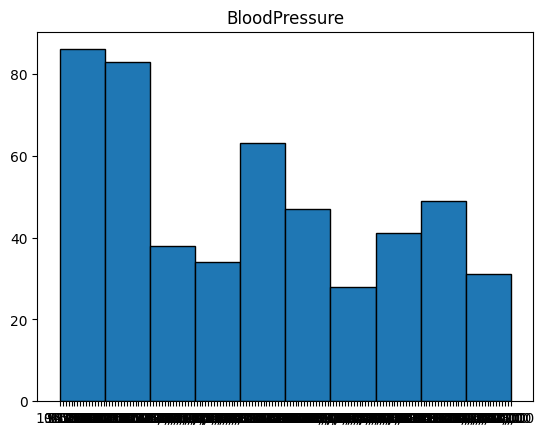

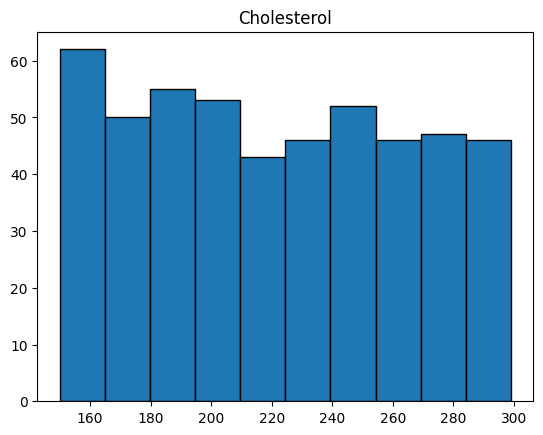

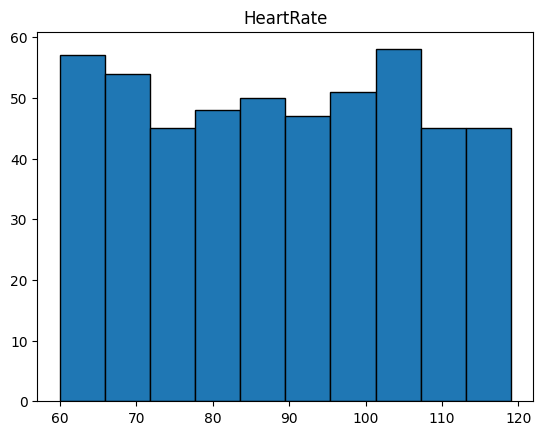

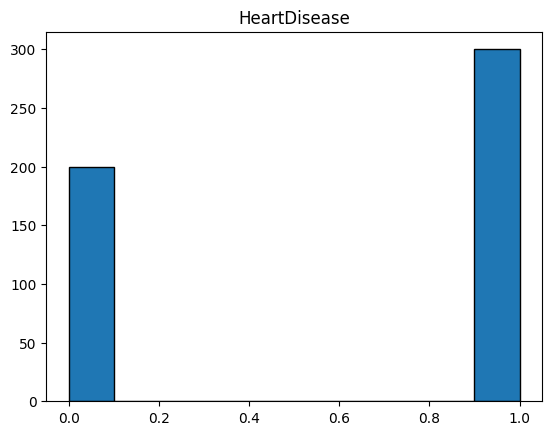

In [255]:
import matplotlib.pyplot as plt

for i in df.columns:
    plt.figure()
    plt.hist(df[i], edgecolor='black')
    plt.title(i)
    plt.show()

¿Parecen correctas estas distribuciones? ¿Qué valores atípicos encontraste? ¿Alguna inconsistencia? ¿Los problemas encontrados podrían ser casos reales?

**Primero que nada la columna 'BloodPressure' esta como un string y debería ser un float por sus 2 decimales, por lo tanto su distribución no se puede interpretar ya que no esta organizado numéricamente de menor a mayor sus intervalos, la columna de Genero tiene errore variados de ortografía lo que afecta la clasificación de frecuencias así mismo el Colesterol y la Fecuencia Cardíaca tiene valores muy altos fuera de lo normal y son muy frecuentes.**

#### Ejercicio 3: Limpieza

Es muy común que haya errores al registrar observaciones. Puede ser que personas diferentes hayan registrado datos con un estilo diferente, o que haya habido un error de dedo. También podrían haber registros duplicados, o datos faltantes.

Por ejemplo, la columna BloodPressure tiene dos estilos diferentes para el punto decimal (americano y europeo).

Utiliza `pandas.Series.str.replace` para cambiar el punto decimal de europeo a americano en la columna de BloodPressure. Después, cambia el tipo de dato de la columna a numérico. Dibuja el histograma de la variable corregida.

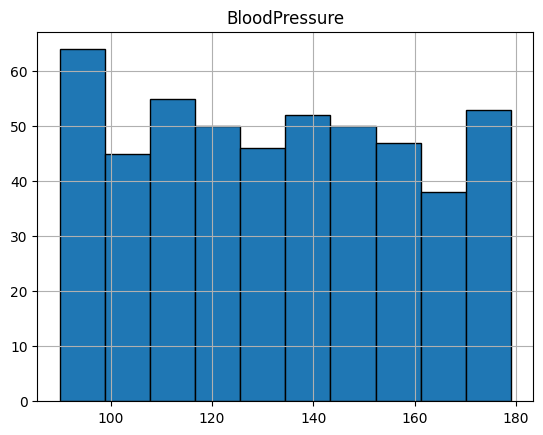

In [256]:
df['BloodPressure'] = (df['BloodPressure'].str.replace(',', '.').astype(float))
plt.figure()
df['BloodPressure'].hist(edgecolor='black')
plt.title('BloodPressure')
plt.show()

La columna Gender tiene también errores de dedo y de estilo. Utiliza `pandas.Series.unique()` para encontrar las formas diferentes en las que se escribió "Hombre" y "Mujer".

In [257]:
df['Gender'].unique()

array(['Hombre   ', 'Mujer', 'ombre', 'mujer', 'MUjer', 'MUJER', 'Mujer{',
       'Hombre}', 'Hombre'], dtype=object)

La diferencia entre una mayúscula y minúscula para una computadora tiene que ver con la tabla ASCII. Para evitar esta variación utiliza `pandas.Series.str.lower()` para convertir todos las mayúsculas en minúsculas. Guarda el resultado en una variable auxiliar. Utiliza `unique()` una vez más para ver el resultado.

In [258]:
gend_min = df['Gender'].str.lower()
gend_min.unique()

array(['hombre   ', 'mujer', 'ombre', 'mujer{', 'hombre}', 'hombre'],
      dtype=object)

Observamos que hay errores como espacios en blanco o errores de dedo. Utiliza `pandas.Series.str.rstrip("xxx")` para limpiar los caracteres indeseados.

In [259]:
gend_min = gend_min.str.rstrip(' ')
gend_min = gend_min.str.rstrip('{')
gend_min = gend_min.str.rstrip('}')
gend_min.unique()

array(['hombre', 'mujer', 'ombre'], dtype=object)

Utiliza un filtro para corregir el typo de la 'h' faltante para la categoría "hombre".

In [260]:
gend_min[gend_min == 'ombre'] = 'hombre'
gend_min.unique()

array(['hombre', 'mujer'], dtype=object)

Asigna "hombre"=1 y "mujer"=0 (Ojo con los tipos de dato. Considera que 0 es diferente a "0").

In [261]:
gend_min[gend_min == 'hombre'] = 1
gend_min[gend_min == 'mujer'] = 0

Reescribe el resultado en el dataset original.

In [262]:
df['Gender'] = gend_min.astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   Gender         500 non-null    int64  
 2   BloodPressure  500 non-null    float64
 3   Cholesterol    500 non-null    int64  
 4   HeartRate      500 non-null    int64  
 5   HeartDisease   500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


Para asegurarnos que no haya duplicados, utiliza `pd.DataFrame.drop_duplicates()`

In [263]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   Gender         500 non-null    int64  
 2   BloodPressure  500 non-null    float64
 3   Cholesterol    500 non-null    int64  
 4   HeartRate      500 non-null    int64  
 5   HeartDisease   500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


Para los valores faltantes se podría imputar, pero por ahora sólo elimínalos (si es que hay) con `pd.DataFrame.dropna()`

In [264]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   Gender         500 non-null    int64  
 2   BloodPressure  500 non-null    float64
 3   Cholesterol    500 non-null    int64  
 4   HeartRate      500 non-null    int64  
 5   HeartDisease   500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


#### Ejercicio 4: Verificación

Ahora que entendemos qué significan nuestras variables y que las limpiamos, vuelve a generar histogramas para cada variable.

In [ ]:
df.describe()   

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,1.000000


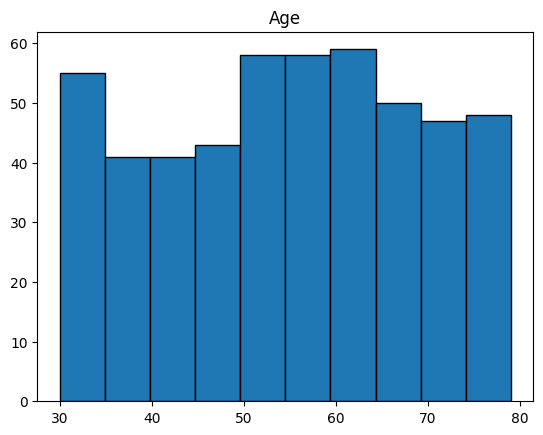

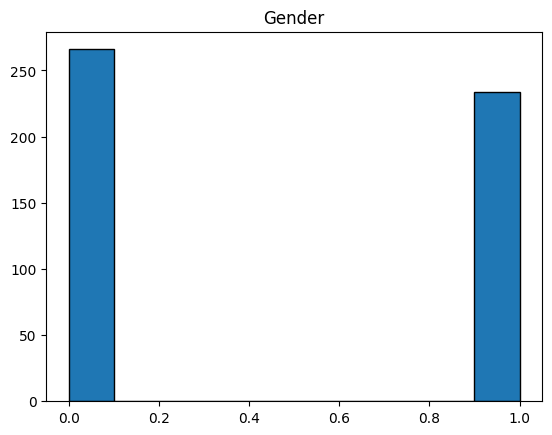

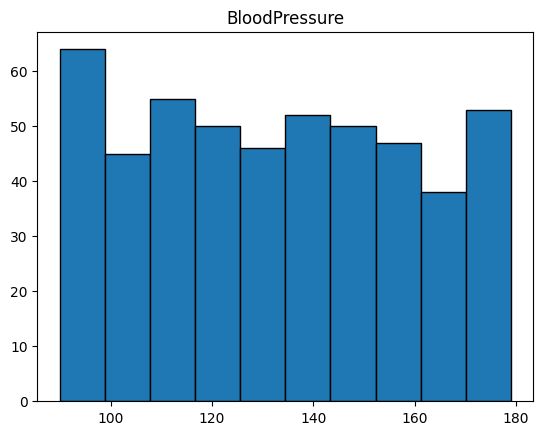

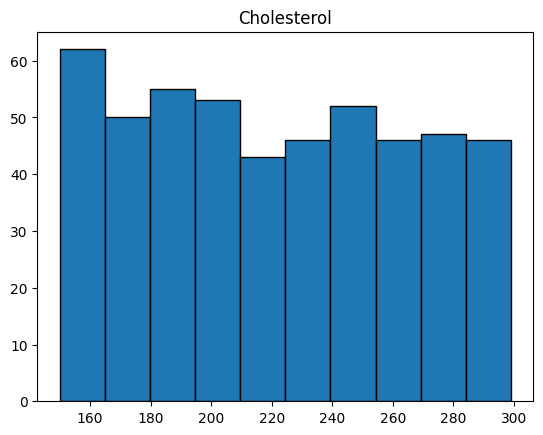

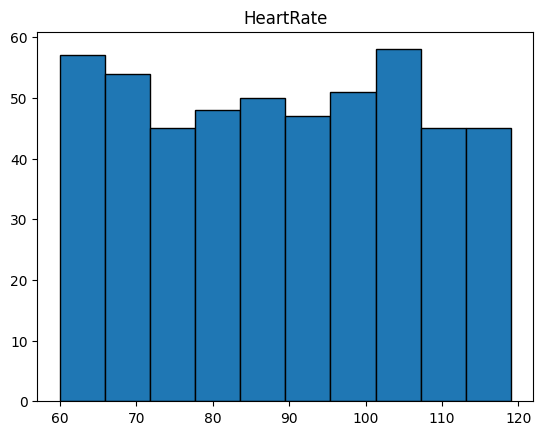

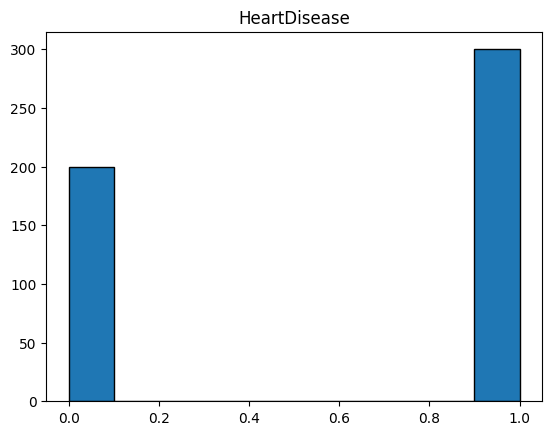

In [266]:
for i in df.columns:
    plt.figure()
    plt.hist(df[i], edgecolor='black')
    plt.title(i)
    plt.show()

Encuentra la siguiente información para las variables numéricas:
- media
- mediana
- desviación estándar
- mínimo
- máximo

Genera un diagrama de caja para cada una. ¿Consideras que hay valores atípicos (outliers)?

In [267]:
stats = pd.DataFrame(index=df.columns, columns=['Media', 'Mediana', 'Desviación Estándar', 'Mínimo', 'Máximo'])
for i in df.columns:
    stats.loc[i, 'Media'] = df[i].mean()
    stats.loc[i, 'Mediana'] = df[i].median()
    stats.loc[i, 'Desviación Estándar'] = df[i].std()
    stats.loc[i, 'Mínimo'] = df[i].min()
    stats.loc[i, 'Máximo'] = df[i].max()

stats

,Media,Mediana,Desviación Estándar,Mínimo,Máximo
Age,54.864,55.0,14.315004,30,79
Gender,0.468,0.0,0.499475,0,1
BloodPressure,132.874,132.0,26.418516,90.0,179.0
Cholesterol,221.5,221.0,43.86363,150,299
HeartRate,88.766,89.0,17.417289,60,119
HeartDisease,0.6,1.0,0.490389,0,1


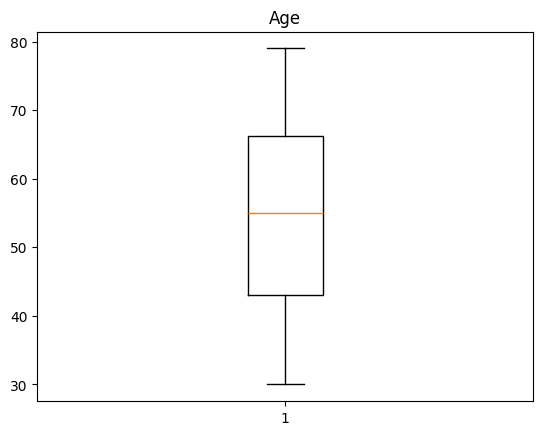

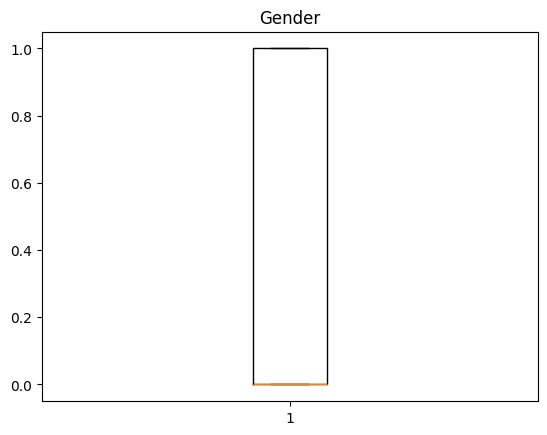

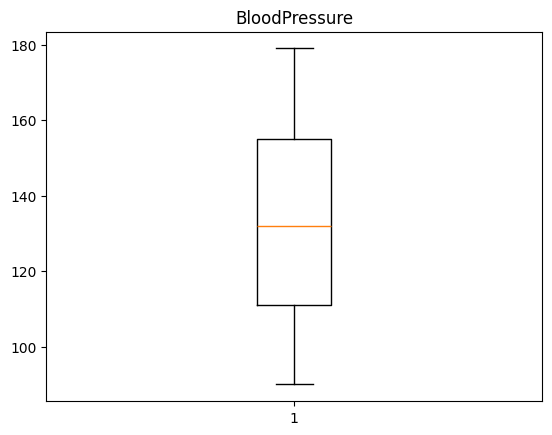

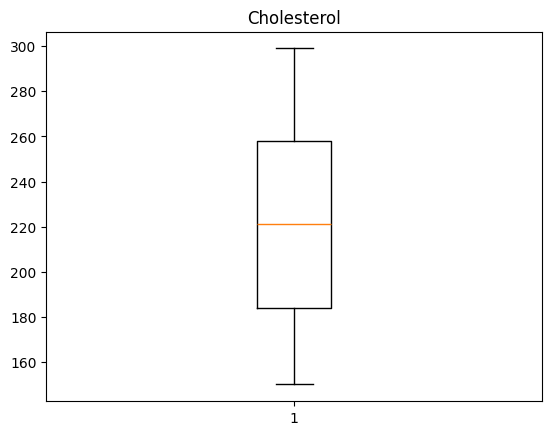

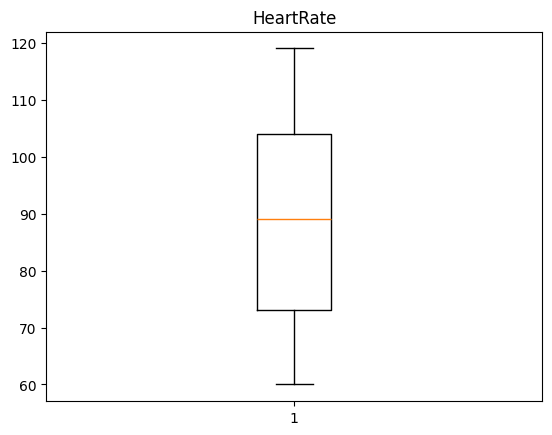

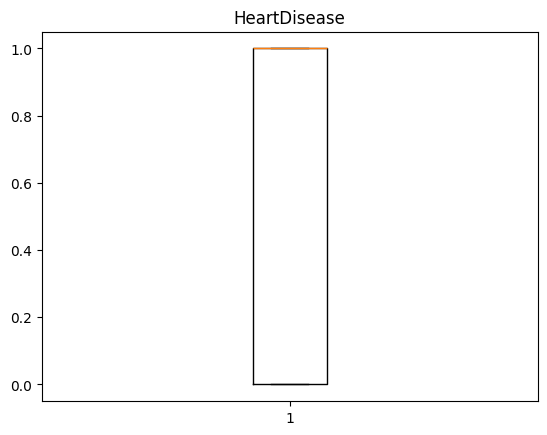

In [268]:
for i in df.columns:
    plt.figure()
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

**Según el Boxplot no muestra tener valores atípicos**

Encuentra la siguiente información para las variables categóricas:
- tabla de frecuencias
- valores únicos

In [269]:
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].unique())

print(df['Gender'].value_counts())
print(df['Gender'].unique())

HeartDisease
1    300
0    200
Name: count, dtype: int64
[1 0]
Gender
0    266
1    234
Name: count, dtype: int64
[1 0]


## Referencia

Dataset original tomado de: https://www.kaggle.com/datasets/shantanugarg274/heart-prediction-dataset-quantum